<a href="https://colab.research.google.com/github/cheikhatdiop00/Colab-AI/blob/main/ESP_ML_TP_Binome.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🛡️ MalwareGuard — Classification de Malwares
## Analyse Statique + Apprentissage Supervisé
Ecole Superieur Polytechnique de Dakar -IABD
# Collaborations:
# **Cheikh DIop**
# **Ngagne Niang**



**Pipeline complet :**
1. Import du dataset CSV depuis Google Drive ou upload direct
2. Analyse exploratoire (EDA)
3. Prétraitement automatique (valeurs manquantes, encodage, normalisation)
4. Entraînement : SVM · Random Forest · KNN
5. Évaluation comparative (F1-Score, Précision, Rappel)
6. Optimisation GridSearchCV du meilleur modèle
7. Sauvegarde du modèle final

---
> ⚙️ Train Model AI

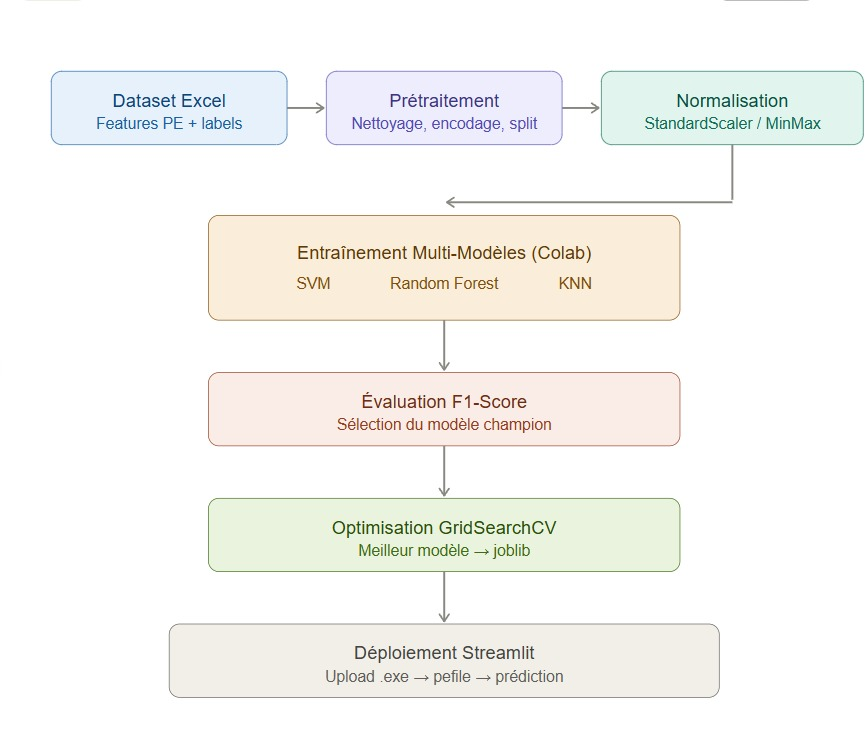

# Importation des Package

In [ ]:
import pandas as pd

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
#normalize
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [ ]:
dataset = pd.read_csv('DatasetmalwareExtrait.csv')
dataset.head()

,AddressOfEntryPoint,MajorLinkerVersion,MajorImageVersion,MajorOperatingSystemVersion,DllCharacteristics,SizeOfStackReserve,NumberOfSections,ResourceSize,legitimate
0,10407,9,6,6,33088,262144,4,952,1
1,5354,9,6,6,33088,262144,4,952,1
2,58807,9,6,6,33088,262144,4,136490,1
3,25166,9,6,6,33088,262144,4,1940,1
4,70387,9,6,6,33088,262144,4,83098,1


In [ ]:
dataset.columns

Index(['AddressOfEntryPoint', 'MajorLinkerVersion', 'MajorImageVersion',
       'MajorOperatingSystemVersion', 'DllCharacteristics',
       'SizeOfStackReserve', 'NumberOfSections', 'ResourceSize', 'legitimate'],
      dtype='object')

# Separation des Future X et Labels y

In [ ]:
X=dataset.iloc[:,:-1].values
y=dataset.iloc[:,-1].values
y

array([1, 1, 1, ..., 0, 0, 0])

In [ ]:
print(dataset.shape)
print(dataset.head())
print(dataset['legitimate'].value_counts())  # distribution sain / malveillant

(137444, 9)
   AddressOfEntryPoint  MajorLinkerVersion  MajorImageVersion  \
0                10407                   9                  6   
1                 5354                   9                  6   
2                58807                   9                  6   
3                25166                   9                  6   
4                70387                   9                  6   

   MajorOperatingSystemVersion  DllCharacteristics  SizeOfStackReserve  \
0                            6               33088              262144   
1                            6               33088              262144   
2                            6               33088              262144   
3                            6               33088              262144   
4                            6               33088              262144   

   NumberOfSections  ResourceSize  legitimate  
0                 4           952           1  
1                 4           952           1  
2       

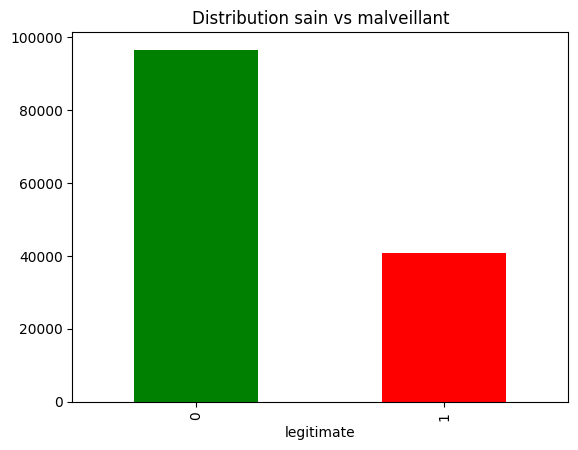

In [ ]:
# Visualisation de la distribution des classes
dataset['legitimate'].value_counts().plot(kind='bar', color=['green','red'])
plt.title("Distribution sain vs malveillant")
plt.show()

# Separation en donnees de TEST ET D'entrainement

In [ ]:
from sklearn.model_selection import  train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,train_size=0.7,random_state=42)

print(len(X_train))
print(len(y_train))

96210
96210


In [ ]:
# Normalisation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
#NORMALIZE PRINT
print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Train: (96210, 8) | Test: (41234, 8)


# Étude Comparative Multimodèle

Entraînement Multi-Modèles (Colab)
# SVM
# Random Forest
# KNN

Trois architectures algorithmiques seront mises en concurrence :
1. Support Vector Machine (SVM) : Pour sa précision dans les espaces de haute
dimension.
2. Random Forest : Pour sa robustesse face au bruit et aux données tabulaires.
3. K-Nearest Neighbors (KNN) : Pour son approche basée sur la proximité géométrique.

Méthodologie et Évaluation
La performance sera évaluée selon la métrique du F1-Score, calculée comme suit :
F1 = 2 ·
Précision · Rappel
Précision + Rappel
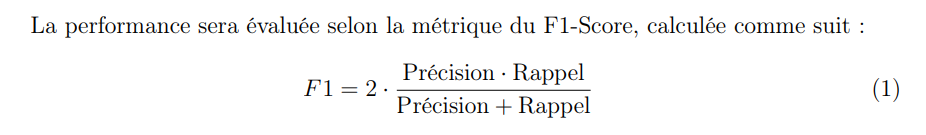


Modèle : SVM | F1-Score : 0.9332
              precision    recall  f1-score   support

        Sain       0.98      0.97      0.97     28884
 Malveillant       0.92      0.94      0.93     12350

    accuracy                           0.96     41234
   macro avg       0.95      0.96      0.95     41234
weighted avg       0.96      0.96      0.96     41234


Modèle : Random Forest | F1-Score : 0.9852
              precision    recall  f1-score   support

        Sain       0.99      0.99      0.99     28884
 Malveillant       0.98      0.99      0.99     12350

    accuracy                           0.99     41234
   macro avg       0.99      0.99      0.99     41234
weighted avg       0.99      0.99      0.99     41234


Modèle : KNN | F1-Score : 0.9680
              precision    recall  f1-score   support

        Sain       0.99      0.98      0.99     28884
 Malveillant       0.96      0.97      0.97     12350

    accuracy                           0.98     41234
   macro avg    

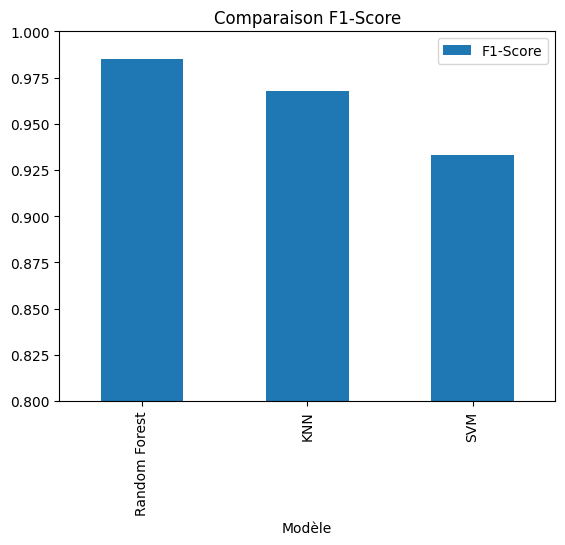

In [ ]:
#MATURE TRAINING

from sklearn.svm import SVC  #SVM
from sklearn.ensemble import RandomForestClassifier #RANDOM FOREST
from sklearn.neighbors import KNeighborsClassifier  # KNN
from sklearn.metrics import f1_score, classification_report, confusion_matrix #METRIC COMPARE TOP MODEL

models = {
    "SVM":           SVC(kernel='rbf', random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "KNN":           KNeighborsClassifier(n_neighbors=5),
}

results = {}

for name, model in models.items():
    # SVM et KNN utilisent les données normalisées
    X_tr = X_train_scaled if name in ["SVM", "KNN"] else X_train
    X_te = X_test_scaled  if name in ["SVM", "KNN"] else X_test

    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)
    f1 = f1_score(y_test, y_pred)
    results[name] = {"model": model, "f1": f1}

    print(f"\n{'='*40}")
    print(f"Modèle : {name} | F1-Score : {f1:.4f}")
    print(classification_report(y_test, y_pred, target_names=["Sain","Malveillant"]))

# Affichage comparatif
pd.DataFrame({"Modèle": list(results.keys()),
              "F1-Score": [v['f1'] for v in results.values()]})\
  .sort_values("F1-Score", ascending=False).plot(x="Modèle", y="F1-Score", kind="bar")
plt.title("Comparaison F1-Score")
plt.ylim(0.8, 1.0)
plt.show()

# Optimisation du Modèle Champion
Le modèle présentant le meilleur F1-Score fera l’objet d’une optimisation avancée via
# la méthode GridSearchCV pour affiner les hyperparamètres.

In [ ]:
from sklearn.model_selection import GridSearchCV

# Sélection automatique du champion
champion_name = max(results, key=lambda k: results[k]['f1'])
print(f"Modèle champion : {champion_name} (F1={results[champion_name]['f1']:.4f})")

# Grilles de paramètres par modèle
param_grids = {
    "SVM": {
        "C": [0.1, 1, 10, 100],
        "gamma": ["scale", "auto"],
        "kernel": ["rbf", "linear"]
    },
    "Random Forest": {
        "n_estimators": [100, 200, 300],
        "max_depth": [None, 10, 20],
        "min_samples_split": [2, 5]
    },
    "KNN": {
        "n_neighbors": [3, 5, 7, 11],
        "weights": ["uniform", "distance"],
        "metric": ["euclidean", "manhattan"]
    }
}

X_tr = X_train_scaled if champion_name in ["SVM","KNN"] else X_train
X_te = X_test_scaled  if champion_name in ["SVM","KNN"] else X_test

champ_model = results[champion_name]["model"].__class__()
grid = GridSearchCV(champ_model, param_grids[champion_name],
                    cv=5, scoring='f1', n_jobs=-1, verbose=1)
grid.fit(X_tr, y_train)

print(f"Meilleurs params : {grid.best_params_}")
print(f"F1 CV : {grid.best_score_:.4f}")

best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_te)
print(f"F1 final : {f1_score(y_test, y_pred_best):.4f}")

Modèle champion : Random Forest (F1=0.9852)
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Meilleurs params : {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 300}
F1 CV : 0.9839
F1 final : 0.9852


# Sauvegarde du modèle

# 3.4 Déploiement et Inférence
Mise en œuvre d’une architecture micro-service permettant :
— L’upload d’un binaire (.exe, .dll).
— L’extraction dynamique via la bibliothèque pefile.
— La prédiction instantanée par le modèle optimisé via une interface FastAPI, Flask
ou Streamlit.

In [ ]:
import joblib
import numpy as np
from sklearn.preprocessing import LabelEncoder

# Recréation et fit du LabelEncoder sur la colonne cible
le_label = LabelEncoder()
le_label.fit(dataset['legitimate'])          # ← adapte au nom exact de votre colonne cible

joblib.dump(best_model,    "model_malware.pkl")
joblib.dump(scaler,        "scaler_malware.pkl")
joblib.dump(list(dataset.drop(columns=['legitimate']).columns), "features_malware.pkl")
joblib.dump(le_label,      "label_encoder.pkl")

print(" 4 fichiers sauvegardés !")

from google.colab import files
files.download("model_malware.pkl")
files.download("scaler_malware.pkl")
files.download("features_malware.pkl")
files.download("label_encoder.pkl")

✅ 4 fichiers sauvegardés !


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **5 Environnement Technique**
— Langage : Python 3.10+
— Analyse PE : pefile
— Machine Learning : Scikit-learn, Pandas, Joblib
# — Déploiement : FastAPI ou Streamlit.


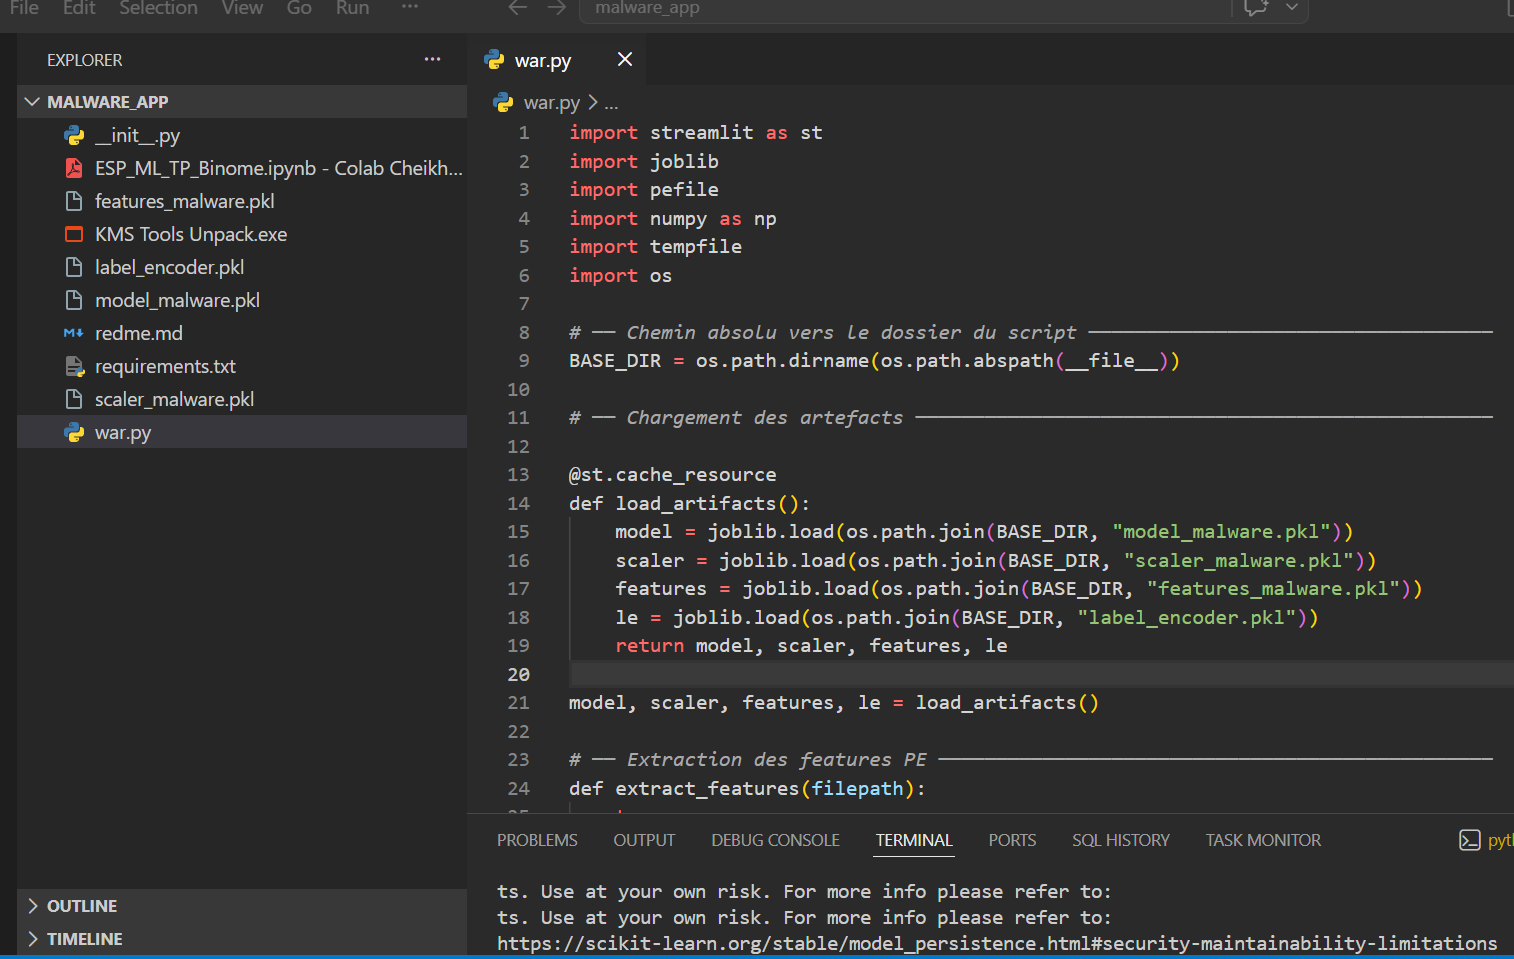

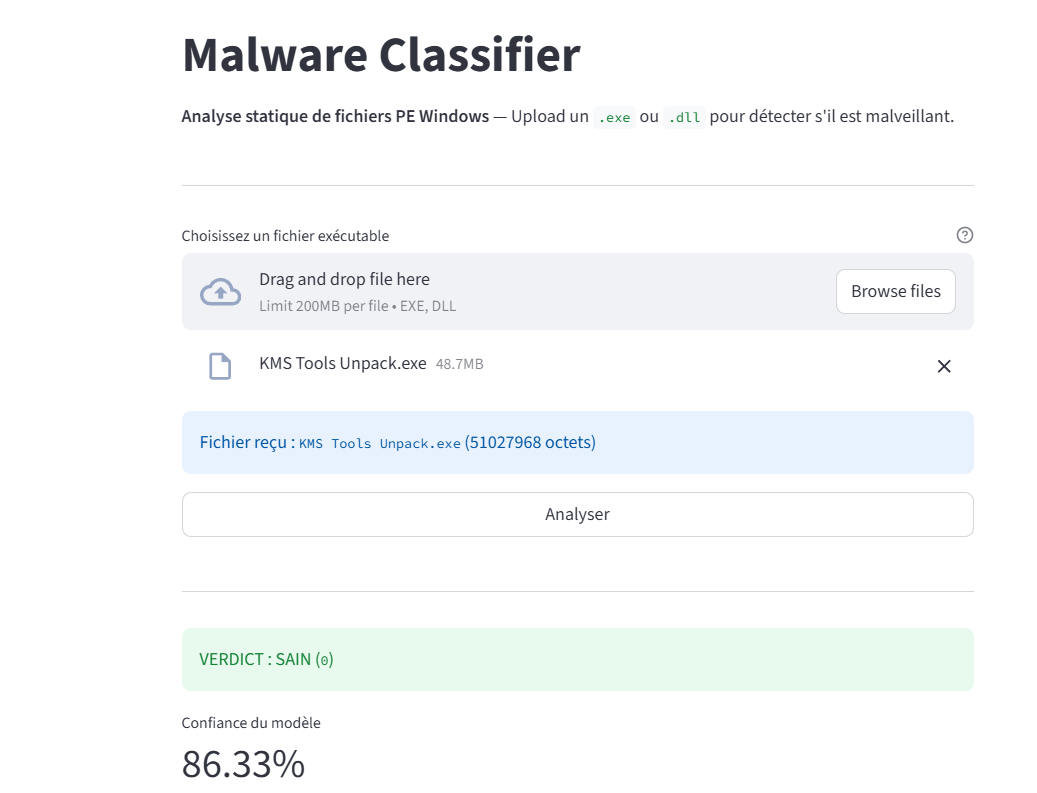

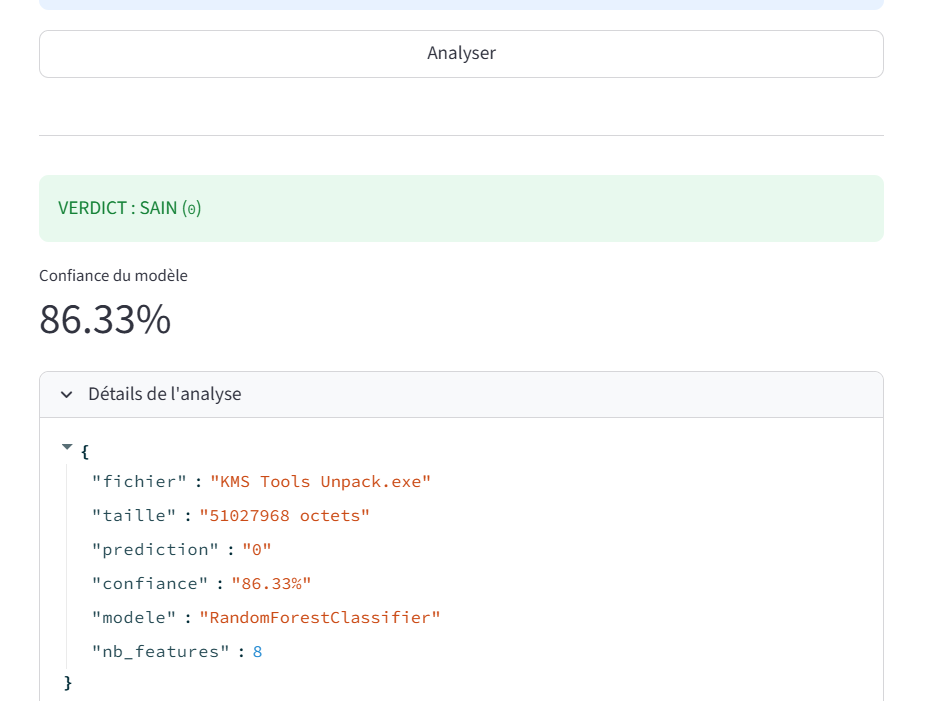

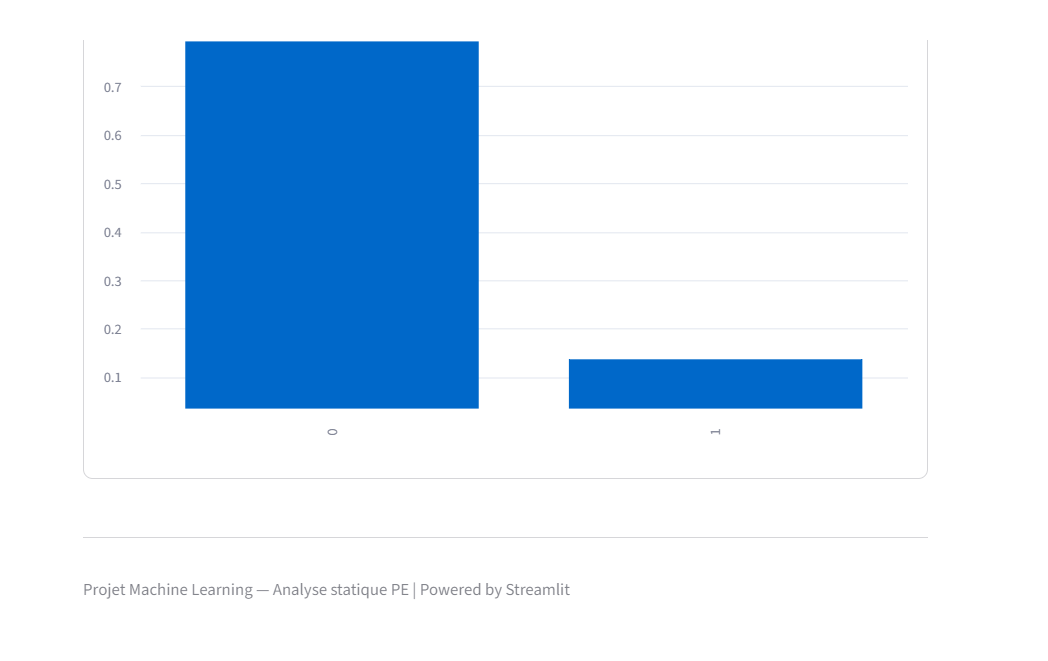

<svg width="100%" viewBox="0 0 680 520" xmlns="http://www.w3.org/2000/svg">
<defs>
  <marker id="arrow" viewBox="0 0 10 10" refX="8" refY="5" markerWidth="6" markerHeight="6" orient="auto-start-reverse">
    <path d="M2 1L8 5L2 9" fill="none" stroke="context-stroke" stroke-width="1.5" stroke-linecap="round" stroke-linejoin="round"/>
  </marker>
</defs>

<style>
  text { font-family: Arial, sans-serif; }
  .th  { font-size: 14px; font-weight: 500; fill: #0C447C; }
  .ts  { font-size: 12px; font-weight: 400; fill: #185FA5; }

  .blue-rect   { fill: #E6F1FB; stroke: #185FA5; }
  .purple-rect { fill: #EEEDFE; stroke: #534AB7; }
  .purple-th   { font-size: 14px; font-weight: 500; fill: #3C3489; }
  .purple-ts   { font-size: 12px; font-weight: 400; fill: #534AB7; }
  .teal-rect   { fill: #E1F5EE; stroke: #0F6E56; }
  .teal-th     { font-size: 14px; font-weight: 500; fill: #085041; }
  .teal-ts     { font-size: 12px; font-weight: 400; fill: #0F6E56; }
  .amber-rect  { fill: #FAEEDA; stroke: #854F0B; }
  .amber-th    { font-size: 14px; font-weight: 500; fill: #633806; }
  .amber-ts    { font-size: 12px; font-weight: 400; fill: #854F0B; }
  .coral-rect  { fill: #FAECE7; stroke: #993C1D; }
  .coral-th    { font-size: 14px; font-weight: 500; fill: #712B13; }
  .coral-ts    { font-size: 12px; font-weight: 400; fill: #993C1D; }
  .green-rect  { fill: #EAF3DE; stroke: #3B6D11; }
  .green-th    { font-size: 14px; font-weight: 500; fill: #27500A; }
  .green-ts    { font-size: 12px; font-weight: 400; fill: #3B6D11; }
  .gray-rect   { fill: #F1EFE8; stroke: #5F5E5A; }
  .gray-th     { font-size: 14px; font-weight: 500; fill: #444441; }
  .gray-ts     { font-size: 12px; font-weight: 400; fill: #5F5E5A; }
  .arr         { stroke: #888780; stroke-width: 1.5; fill: none; }
</style>

<!-- Phase 1: Dataset -->
<rect class="blue-rect" x="30" y="30" width="180" height="56" rx="8" stroke-width="0.5"/>
<text class="th" x="120" y="52" text-anchor="middle" dominant-baseline="central">Dataset Excel</text>
<text class="ts" x="120" y="70" text-anchor="middle" dominant-baseline="central">Features PE + labels</text>

<line x1="210" y1="58" x2="238" y2="58" class="arr" marker-end="url(#arrow)"/>

<!-- Phase 2: Prétraitement -->
<rect class="purple-rect" x="240" y="30" width="180" height="56" rx="8" stroke-width="0.5"/>
<text class="purple-th" x="330" y="52" text-anchor="middle" dominant-baseline="central">Prétraitement</text>
<text class="purple-ts" x="330" y="70" text-anchor="middle" dominant-baseline="central">Nettoyage, encodage, split</text>

<line x1="420" y1="58" x2="448" y2="58" class="arr" marker-end="url(#arrow)"/>

<!-- Phase 3: Normalisation -->
<rect class="teal-rect" x="450" y="30" width="200" height="56" rx="8" stroke-width="0.5"/>
<text class="teal-th" x="550" y="52" text-anchor="middle" dominant-baseline="central">Normalisation</text>
<text class="teal-ts" x="550" y="70" text-anchor="middle" dominant-baseline="central">StandardScaler / MinMax</text>

<!-- Arrow down then left -->
<line x1="550" y1="86" x2="550" y2="128" class="arr"/>
<line x1="550" y1="130" x2="332" y2="130" class="arr" marker-end="url(#arrow)"/>

<!-- Phase 4: Entraînement -->
<rect class="amber-rect" x="150" y="140" width="360" height="80" rx="8" stroke-width="0.5"/>
<text class="amber-th" x="330" y="168" text-anchor="middle" dominant-baseline="central">Entraînement Multi-Modèles (Colab)</text>
<text class="amber-ts" x="230" y="192" text-anchor="middle" dominant-baseline="central">SVM</text>
<text class="amber-ts" x="330" y="192" text-anchor="middle" dominant-baseline="central">Random Forest</text>
<text class="amber-ts" x="430" y="192" text-anchor="middle" dominant-baseline="central">KNN</text>

<line x1="330" y1="220" x2="330" y2="258" class="arr" marker-end="url(#arrow)"/>

<!-- Phase 5: Évaluation -->
<rect class="coral-rect" x="150" y="260" width="360" height="56" rx="8" stroke-width="0.5"/>
<text class="coral-th" x="330" y="282" text-anchor="middle" dominant-baseline="central">Évaluation F1-Score</text>
<text class="coral-ts" x="330" y="300" text-anchor="middle" dominant-baseline="central">Sélection du modèle champion</text>

<line x1="330" y1="316" x2="330" y2="354" class="arr" marker-end="url(#arrow)"/>

<!-- Phase 6: GridSearchCV -->
<rect class="green-rect" x="150" y="356" width="360" height="56" rx="8" stroke-width="0.5"/>
<text class="green-th" x="330" y="378" text-anchor="middle" dominant-baseline="central">Optimisation GridSearchCV</text>
<text class="green-ts" x="330" y="396" text-anchor="middle" dominant-baseline="central">Meilleur modèle → joblib</text>

<line x1="330" y1="412" x2="330" y2="450" class="arr" marker-end="url(#arrow)"/>

<!-- Phase 7: Flask -->
<rect class="gray-rect" x="120" y="452" width="420" height="56" rx="8" stroke-width="0.5"/>
<text class="gray-th" x="330" y="474" text-anchor="middle" dominant-baseline="central">Déploiement StreamLite</text>
<text class="gray-ts" x="330" y="492" text-anchor="middle" dominant-baseline="central">Upload .exe → pefile → prédiction</text>
</svg>

<svg width="100%" viewBox="0 0 680 520" xmlns="http://www.w3.org/2000/svg">
<defs>
  <marker id="arrow" viewBox="0 0 10 10" refX="8" refY="5" markerWidth="6" markerHeight="6" orient="auto-start-reverse">
    <path d="M2 1L8 5L2 9" fill="none" stroke="context-stroke" stroke-width="1.5" stroke-linecap="round" stroke-linejoin="round"/>
  </marker>
</defs>

<style>
  text { font-family: Arial, sans-serif; }
  .th  { font-size: 14px; font-weight: 500; fill: #0C447C; }
  .ts  { font-size: 12px; font-weight: 400; fill: #185FA5; }

  .blue-rect   { fill: #E6F1FB; stroke: #185FA5; }
  .purple-rect { fill: #EEEDFE; stroke: #534AB7; }
  .purple-th   { font-size: 14px; font-weight: 500; fill: #3C3489; }
  .purple-ts   { font-size: 12px; font-weight: 400; fill: #534AB7; }
  .teal-rect   { fill: #E1F5EE; stroke: #0F6E56; }
  .teal-th     { font-size: 14px; font-weight: 500; fill: #085041; }
  .teal-ts     { font-size: 12px; font-weight: 400; fill: #0F6E56; }
  .amber-rect  { fill: #FAEEDA; stroke: #854F0B; }
  .amber-th    { font-size: 14px; font-weight: 500; fill: #633806; }
  .amber-ts    { font-size: 12px; font-weight: 400; fill: #854F0B; }
  .coral-rect  { fill: #FAECE7; stroke: #993C1D; }
  .coral-th    { font-size: 14px; font-weight: 500; fill: #712B13; }
  .coral-ts    { font-size: 12px; font-weight: 400; fill: #993C1D; }
  .green-rect  { fill: #EAF3DE; stroke: #3B6D11; }
  .green-th    { font-size: 14px; font-weight: 500; fill: #27500A; }
  .green-ts    { font-size: 12px; font-weight: 400; fill: #3B6D11; }
  .gray-rect   { fill: #F1EFE8; stroke: #5F5E5A; }
  .gray-th     { font-size: 14px; font-weight: 500; fill: #444441; }
  .gray-ts     { font-size: 12px; font-weight: 400; fill: #5F5E5A; }
  .arr         { stroke: #888780; stroke-width: 1.5; fill: none; }
</style>

<!-- Phase 1: Dataset -->
<rect class="blue-rect" x="30" y="30" width="180" height="56" rx="8" stroke-width="0.5"/>
<text class="th" x="120" y="52" text-anchor="middle" dominant-baseline="central">Dataset Excel</text>
<text class="ts" x="120" y="70" text-anchor="middle" dominant-baseline="central">Features PE + labels</text>

<line x1="210" y1="58" x2="238" y2="58" class="arr" marker-end="url(#arrow)"/>

<!-- Phase 2: Prétraitement -->
<rect class="purple-rect" x="240" y="30" width="180" height="56" rx="8" stroke-width="0.5"/>
<text class="purple-th" x="330" y="52" text-anchor="middle" dominant-baseline="central">Prétraitement</text>
<text class="purple-ts" x="330" y="70" text-anchor="middle" dominant-baseline="central">Nettoyage, encodage, split</text>

<line x1="420" y1="58" x2="448" y2="58" class="arr" marker-end="url(#arrow)"/>

<!-- Phase 3: Normalisation -->
<rect class="teal-rect" x="450" y="30" width="200" height="56" rx="8" stroke-width="0.5"/>
<text class="teal-th" x="550" y="52" text-anchor="middle" dominant-baseline="central">Normalisation</text>
<text class="teal-ts" x="550" y="70" text-anchor="middle" dominant-baseline="central">StandardScaler / MinMax</text>

<!-- Arrow down then left -->
<line x1="550" y1="86" x2="550" y2="128" class="arr"/>
<line x1="550" y1="130" x2="332" y2="130" class="arr" marker-end="url(#arrow)"/>

<!-- Phase 4: Entraînement -->
<rect class="amber-rect" x="150" y="140" width="360" height="80" rx="8" stroke-width="0.5"/>
<text class="amber-th" x="330" y="168" text-anchor="middle" dominant-baseline="central">Entraînement Multi-Modèles (Colab)</text>
<text class="amber-ts" x="230" y="192" text-anchor="middle" dominant-baseline="central">SVM</text>
<text class="amber-ts" x="330" y="192" text-anchor="middle" dominant-baseline="central">Random Forest</text>
<text class="amber-ts" x="430" y="192" text-anchor="middle" dominant-baseline="central">KNN</text>

<line x1="330" y1="220" x2="330" y2="258" class="arr" marker-end="url(#arrow)"/>

<!-- Phase 5: Évaluation -->
<rect class="coral-rect" x="150" y="260" width="360" height="56" rx="8" stroke-width="0.5"/>
<text class="coral-th" x="330" y="282" text-anchor="middle" dominant-baseline="central">Évaluation F1-Score</text>
<text class="coral-ts" x="330" y="300" text-anchor="middle" dominant-baseline="central">Sélection du modèle champion</text>

<line x1="330" y1="316" x2="330" y2="354" class="arr" marker-end="url(#arrow)"/>

<!-- Phase 6: GridSearchCV -->
<rect class="green-rect" x="150" y="356" width="360" height="56" rx="8" stroke-width="0.5"/>
<text class="green-th" x="330" y="378" text-anchor="middle" dominant-baseline="central">Optimisation GridSearchCV</text>
<text class="green-ts" x="330" y="396" text-anchor="middle" dominant-baseline="central">Meilleur modèle → joblib</text>

<line x1="330" y1="412" x2="330" y2="450" class="arr" marker-end="url(#arrow)"/>

<!-- Phase 7: Flask -->
<rect class="gray-rect" x="120" y="452" width="420" height="56" rx="8" stroke-width="0.5"/>
<text class="gray-th" x="330" y="474" text-anchor="middle" dominant-baseline="central">Déploiement StreamLite </text>
<text class="gray-ts" x="330" y="492" text-anchor="middle" dominant-baseline="central">Upload .exe → pefile → prédiction</text>
</svg>